#**Car Insurance Claim Prediction**



>
***Goal: Predict whether a customer will make an insurance claim.***


Insurance companies rely heavily on data to estimate customer risk.
In this project, the objective is to build a machine learning model that predicts whether a policyholder will make a claim, based on demographic, financial, driving history, and vehicle-related features.

<center><div style="text-align:center;">
<img src="https://unique-autocollision.com/wp-content/uploads/2025/05/affordable-car-insurance-1024x682-1.jpg" width="500">
</div></center>

# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# **Load data**

In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/car_insurance (1).csv")
df

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,323164,1,0,10-19y,university,upper class,0.582787,1.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,1,0.0
9996,910346,1,0,10-19y,none,middle class,0.522231,1.0,after 2015,0.0,1.0,32765,NaN,sedan,1,0,0,0.0
9997,468409,1,1,0-9y,high school,middle class,0.470940,1.0,before 2015,0.0,1.0,10238,14000.0,sedan,0,0,0,0.0
9998,903459,1,0,10-19y,high school,poverty,0.364185,0.0,before 2015,0.0,1.0,10238,13000.0,sedan,2,0,1,1.0


# **Data understanding**

In [3]:
df.shape

(10000, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

Some variables contain missing values, particularly credit_score, annual_mileage, and vehicle_ownership, which should be handled during the data preprocessing stage before training the machine learning model

In [5]:
df.describe(include="all")

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,10000,10000,10000,9018.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,9043.000000,10000,10000.000000,10000.00000,10000.000000,10000.000000
unique,NaN,NaN,NaN,4,3,4,NaN,NaN,2,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,0-9y,high school,upper class,NaN,NaN,before 2015,NaN,NaN,NaN,NaN,sedan,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,3530,4157,4336,NaN,NaN,6967,NaN,NaN,NaN,NaN,9523,NaN,NaN,NaN,NaN
mean,500521.906800,1.489500,0.499000,NaN,NaN,NaN,0.515813,0.697000,NaN,0.498200,0.688800,19864.548400,11697.003207,NaN,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,NaN,NaN,NaN,0.137688,0.459578,NaN,0.500022,0.463008,18915.613855,2818.434528,NaN,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,NaN,NaN,NaN,0.053358,0.000000,NaN,0.000000,0.000000,10238.000000,2000.000000,NaN,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,NaN,NaN,NaN,0.417191,0.000000,NaN,0.000000,0.000000,10238.000000,10000.000000,NaN,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,NaN,NaN,NaN,0.525033,1.000000,NaN,0.000000,1.000000,10238.000000,12000.000000,NaN,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,NaN,NaN,NaN,0.618312,1.000000,NaN,1.000000,1.000000,32765.000000,14000.000000,NaN,2.000000,0.00000,2.000000,1.000000


In [6]:
df.isna().sum()

,0
id,0
age,0
gender,0
driving_experience,0
education,0
income,0
credit_score,982
vehicle_ownership,0
vehicle_year,0
married,0


# **Data cleaning**

In [7]:
#Delete id
df = df.drop(columns=["id"])

In [8]:
df = df.copy()

In [9]:
for col in df.select_dtypes(include=["number"]).columns:
    df[col] = df[col].fillna(df[col].median())

In [11]:
#For cetegorical data
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# **Exploratory Data Analysis**

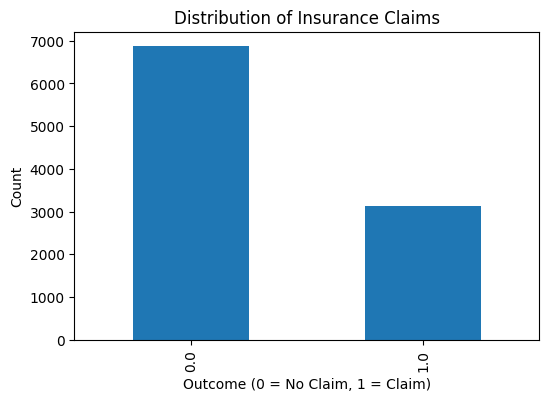

In [12]:
claim_counts = df["outcome"].value_counts().sort_index()

plt.figure(figsize=(6,4))
claim_counts.plot(kind="bar")
plt.title("Distribution of Insurance Claims")
plt.xlabel("Outcome (0 = No Claim, 1 = Claim)")
plt.ylabel("Count")
plt.show()


1.   The distribution shows that most customers did not make an insurance claim (outcome = 0), while a smaller proportion of customers made a claim (outcome = 1).
2.   This indicates that the dataset is imbalanced, with significantly more non-claim cases than claim cases, which may influence the performance of machine learning models.



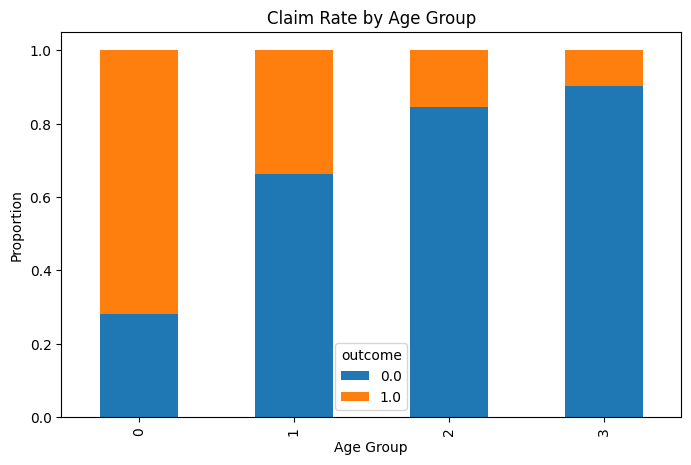

In [13]:
#Claims par âge
age_claim = pd.crosstab(df["age"], df["outcome"], normalize="index")
age_claim.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Claim Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.show()

The chart shows that younger drivers (age group 0) have a higher proportion of insurance claims compared to older age groups.

As the age group increases, the claim rate decreases, indicating that more experienced or older drivers are less likely to make an insurance claim.

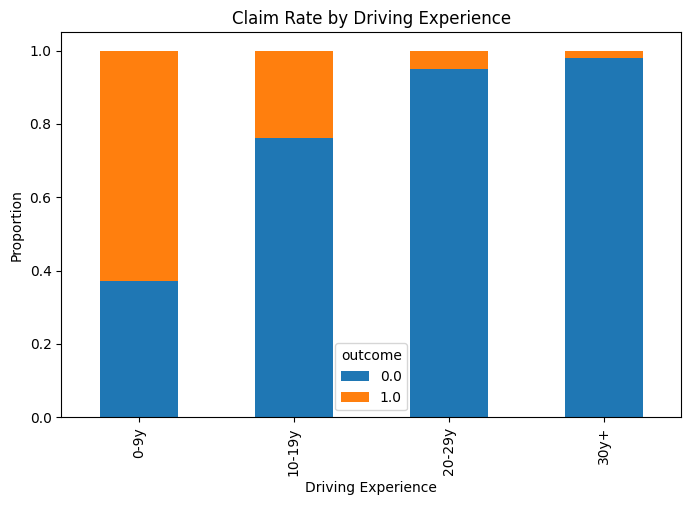

In [15]:
#C. Claims selon l’expérience de conduite
exp_claim = pd.crosstab(df["driving_experience"], df["outcome"], normalize="index")
exp_claim.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Claim Rate by Driving Experience")
plt.xlabel("Driving Experience")
plt.ylabel("Proportion")
plt.show()

The chart shows that drivers with less driving experience (0–9 years) have a higher proportion of insurance claims compared to more experienced drivers.

As driving experience increases, the claim rate decreases, indicating that experienced drivers are less likely to file an insurance claim.

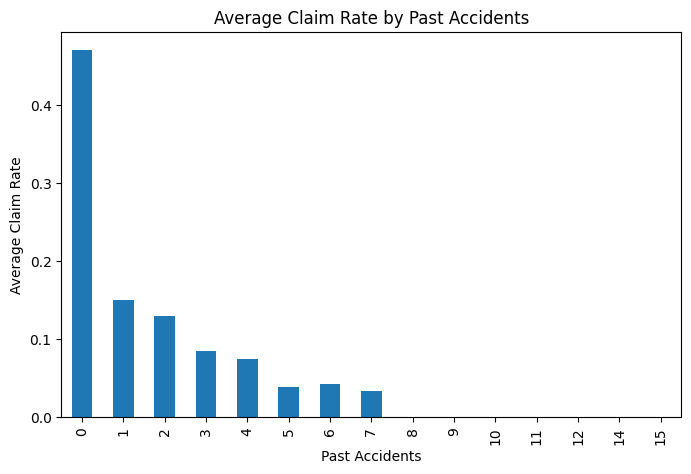

In [16]:
#Claims selon les accidents passés
past_acc_claim = df.groupby("past_accidents")["outcome"].mean()

plt.figure(figsize=(8,5))
past_acc_claim.plot(kind="bar")
plt.title("Average Claim Rate by Past Accidents")
plt.xlabel("Past Accidents")
plt.ylabel("Average Claim Rate")
plt.show()

The chart shows that drivers with no past accidents have the highest average claim rate in the dataset.

As the number of past accidents increases, the average claim rate generally decreases, suggesting a possible imbalance or fewer observations for higher accident counts.

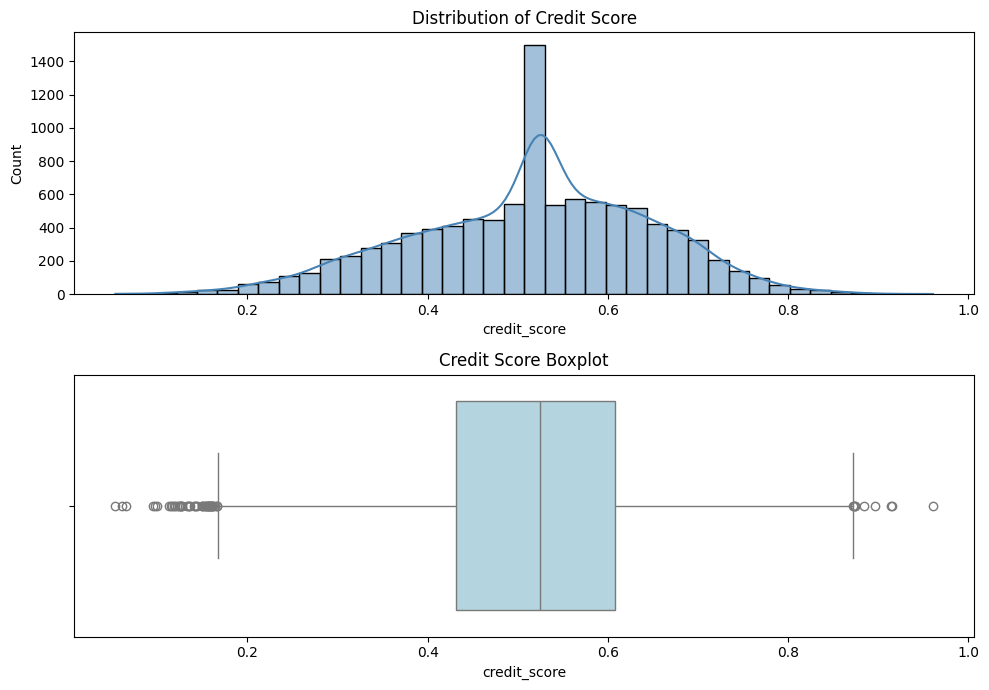

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,1, figsize=(10,7))

sns.histplot(df["credit_score"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Credit Score")

sns.boxplot(x=df["credit_score"], ax=axes[1], color="lightblue")
axes[1].set_title("Credit Score Boxplot")

plt.tight_layout()
plt.show()

The credit score distribution is approximately centered around 0.5–0.6, indicating that most customers have a moderate credit score.

The boxplot shows the presence of some outliers at both low and high credit score values, suggesting variability in the financial profiles of customers.

# **Preprocessing**

In [18]:
X = df.drop(columns=["outcome"])
y = df["outcome"]

In [19]:
#Encoder
X = pd.get_dummies(X, drop_first=True)

In [20]:
#Train/Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [21]:
#Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# **Baseline Model**

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train_scaled, y_train)

y_pred_base = baseline_model.predict(X_test_scaled)
y_prob_base = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Baseline ROC AUC:", roc_auc_score(y_test, y_prob_base))

Baseline Accuracy: 0.84
Baseline ROC AUC: 0.8962274185498332


# **Model Optimization**

In [25]:
params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    params,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.9068469324519727


In [26]:
best_model = grid.best_estimator_
best_model

LogisticRegression(C=1, max_iter=2000, penalty='l1', solver='liblinear')

# **Final evaluation**

In [27]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Final ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Final Accuracy: 0.8396
Final ROC AUC: 0.8962646095576426

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.89      0.88      1717
         1.0       0.75      0.74      0.74       783

    accuracy                           0.84      2500
   macro avg       0.81      0.81      0.81      2500
weighted avg       0.84      0.84      0.84      2500



1.   The model achieves an accuracy of about 0.84 and a ROC AUC of 0.90, indicating a strong ability to distinguish between customers who will make a claim and those who will not.

2.   The performance is better for the non-claim class (0) than for the claim class (1), suggesting the model predicts non-claims more accurately than claims.


# **Confusion Matrix**

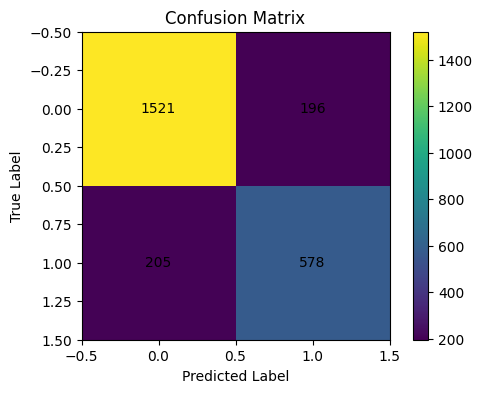

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()



1.  The confusion matrix shows that the model correctly classified 1521 non-claim cases (true negatives) and 578 claim cases (true positives).

2.   However, the model made 196 false positives and 205 false negatives, indicating that some claims were misclassified as non-claims and vice versa.



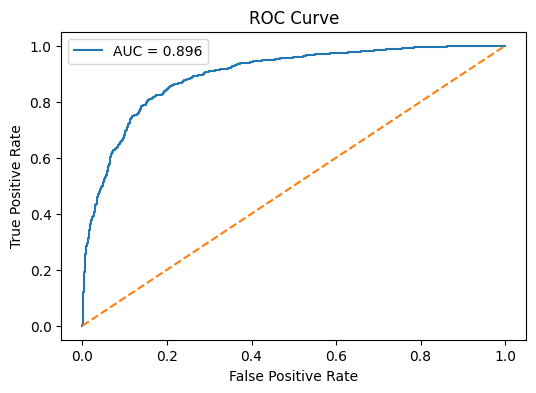

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC curve shows that the model has a strong classification performance with an AUC of 0.896, indicating a high ability to distinguish between claim and non-claim customers.

Since the curve is well above the diagonal line (random classifier), the model performs significantly better than random guessing in predicting insurance claims.

# **Feature Importance**

In [30]:
feature_importance = pd.Series(
    best_model.coef_[0],
    index=X.columns
).sort_values()

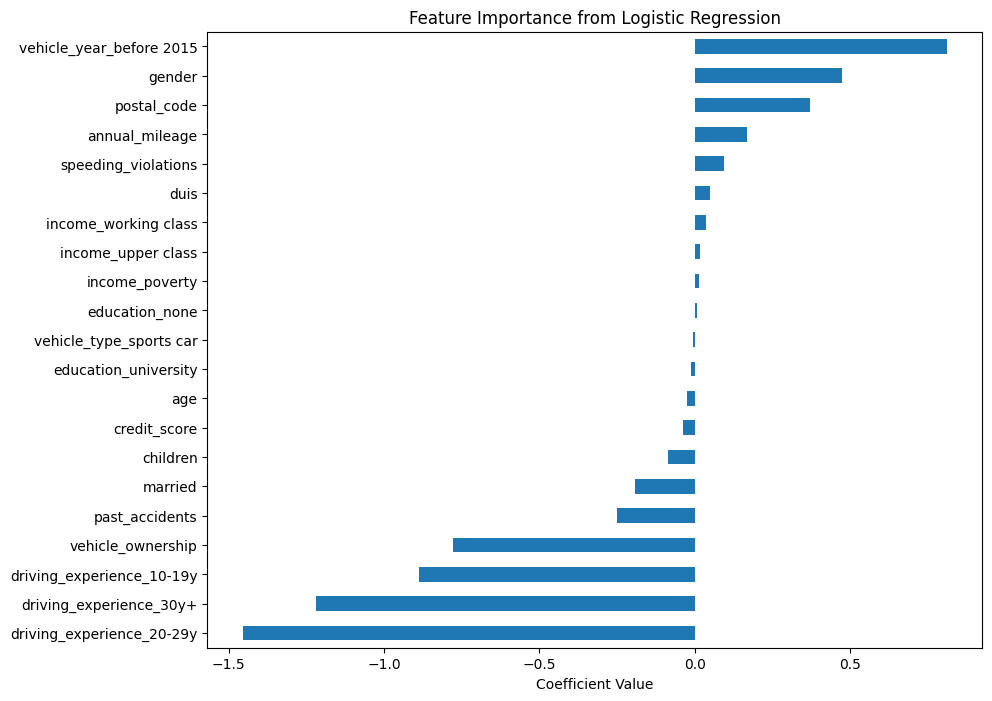

In [31]:
plt.figure(figsize=(10,8))
feature_importance.plot(kind="barh")
plt.title("Feature Importance from Logistic Regression")
plt.xlabel("Coefficient Value")
plt.show()

The feature importance plot shows that vehicle year, gender, postal code, and annual mileage have the strongest positive influence on predicting insurance claims.

In contrast, variables related to driving experience and vehicle ownership have negative coefficients, indicating that more experienced drivers or certain ownership characteristics are associated with a lower probability of making a claim.

In [32]:
top_10 = feature_importance.abs().sort_values(ascending=False).head(10)
top_10

,0
driving_experience_20-29y,1.455505
driving_experience_30y+,1.218425
driving_experience_10-19y,0.886348
vehicle_year_before 2015,0.812677
vehicle_ownership,0.778616
gender,0.472693
postal_code,0.372397
past_accidents,0.250950
married,0.192360
annual_mileage,0.169744


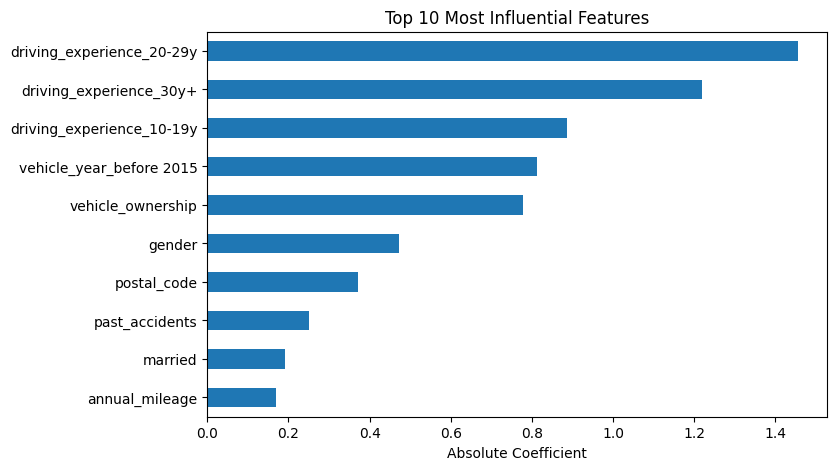

In [33]:
plt.figure(figsize=(8,5))
top_10.sort_values().plot(kind="barh")
plt.title("Top 10 Most Influential Features")
plt.xlabel("Absolute Coefficient")
plt.show()

In [34]:
# prendre le premier client du test set
sample = X_test.iloc[[0]]

# appliquer le scaling
sample_scaled = scaler.transform(sample)

# prediction
prediction = best_model.predict(sample_scaled)
probability = best_model.predict_proba(sample_scaled)[:,1]

print("Prediction:", prediction[0])
print("Probability of claim:", probability[0])

Prediction: 0.0
Probability of claim: 0.029736207827633643


In [35]:
print("Actual value:", y_test.iloc[0])

Actual value: 0.0


In [36]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- widgets de saisie ---
age = widgets.Dropdown(
    options=[0, 1, 2, 3],
    value=1,
    description="Age:"
)

gender = widgets.Dropdown(
    options=[0, 1],
    value=1,
    description="Gender:"
)

driving_experience = widgets.Dropdown(
    options=["0-9y", "10-19y", "20-29y", "30y+"],
    value="10-19y",
    description="Driving exp:"
)

education = widgets.Dropdown(
    options=["none", "high school", "university"],
    value="high school",
    description="Education:"
)

income = widgets.Dropdown(
    options=["poverty", "working class", "middle class", "upper class"],
    value="working class",
    description="Income:"
)

credit_score = widgets.FloatSlider(
    value=0.50, min=0.0, max=1.0, step=0.01,
    description="Credit score:"
)

vehicle_ownership = widgets.Dropdown(
    options=[0.0, 1.0],
    value=1.0,
    description="Own vehicle:"
)

vehicle_year = widgets.Dropdown(
    options=["before 2015", "after 2015"],
    value="before 2015",
    description="Vehicle year:"
)

married = widgets.Dropdown(
    options=[0.0, 1.0],
    value=0.0,
    description="Married:"
)

children = widgets.IntSlider(
    value=0, min=0, max=5, step=1,
    description="Children:"
)

postal_code = widgets.IntText(
    value=10238,
    description="Postal code:"
)

annual_mileage = widgets.IntSlider(
    value=12000, min=1000, max=30000, step=500,
    description="Mileage:"
)

vehicle_type = widgets.Dropdown(
    options=["sedan", "sports car"],
    value="sedan",
    description="Vehicle type:"
)

speeding_violations = widgets.IntSlider(
    value=0, min=0, max=10, step=1,
    description="Speeding:"
)

duis = widgets.IntSlider(
    value=0, min=0, max=5, step=1,
    description="DUIs:"
)

past_accidents = widgets.IntSlider(
    value=0, min=0, max=10, step=1,
    description="Accidents:"
)

predict_button = widgets.Button(
    description="Predict claim risk",
    button_style="success"
)

output = widgets.Output()

# --- fonction de prédiction ---
def predict_claim(b):
    with output:
        clear_output()

        # 1) construire le nouveau client brut
        new_client_raw = pd.DataFrame({
            "age": [age.value],
            "gender": [gender.value],
            "driving_experience": [driving_experience.value],
            "education": [education.value],
            "income": [income.value],
            "credit_score": [credit_score.value],
            "vehicle_ownership": [vehicle_ownership.value],
            "vehicle_year": [vehicle_year.value],
            "married": [married.value],
            "children": [children.value],
            "postal_code": [postal_code.value],
            "annual_mileage": [annual_mileage.value],
            "vehicle_type": [vehicle_type.value],
            "speeding_violations": [speeding_violations.value],
            "duis": [duis.value],
            "past_accidents": [past_accidents.value]
        })

        # 2) encoder comme X
        new_client_encoded = pd.get_dummies(new_client_raw, drop_first=True)

        # 3) aligner les colonnes avec celles utilisées à l'entraînement
        new_client_encoded = new_client_encoded.reindex(columns=X.columns, fill_value=0)

        # 4) scaling
        new_client_scaled = scaler.transform(new_client_encoded)

        # 5) prédiction
        prediction = best_model.predict(new_client_scaled)[0]
        probability = best_model.predict_proba(new_client_scaled)[0, 1]

        # 6) affichage
        print("Client data:")
        display(new_client_raw)

        print(f"Prediction: {int(prediction)}")
        print(f"Probability of claim: {probability:.2%}")

        if prediction == 1:
            print("Interpretation: high risk of making a claim.")
        else:
            print("Interpretation: low risk of making a claim.")

predict_button.on_click(predict_claim)

# --- affichage de l'interface ---
ui = widgets.VBox([
    age, gender, driving_experience, education, income,
    credit_score, vehicle_ownership, vehicle_year, married,
    children, postal_code, annual_mileage, vehicle_type,
    speeding_violations, duis, past_accidents,
    predict_button, output
])

display(ui)